In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1: Завдання

**1.1: Завантаження та Data Cleaning.** Завантажити датасет "Automobile Data Set" за прямим посиланням. Обробити пропущені значення (які позначені як `?`): видалити рядки без вказаної ціни, а інші пропуски заповнити медіанними або найчастішими значеннями.

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

def load_and_clean_auto_data():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
    
    headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
               "num-of-doors", "body-style", "drive-wheels", "engine-location",
               "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
               "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
               "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

    print("Завантаження даних...")
    df = pd.read_csv(url, names=headers, na_values="?")
    print(f"Розмір до очищення: {df.shape}")

    df.dropna(subset=['price'], inplace=True)

    for col in ['normalized-losses', 'horsepower', 'bore', 'stroke', 'peak-rpm']:
        df[col] = df[col].fillna(df[col].median())

    df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

    print(f"Розмір після очищення: {df.shape}")
    print("Кількість пропусків у датасеті:", df.isnull().sum().max())
    
    return df

df = load_and_clean_auto_data()
display(df.head())

Завантаження даних...
Розмір до очищення: (205, 26)
Розмір після очищення: (201, 26)
Кількість пропусків у датасеті: 0


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


# 2. Побудова графіків залежності

**Завдання:** Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

Будуємо `scatterplot` (діаграму розсіювання), щоб побачити, як потужність двигуна (`horsepower`) впливає на ціну автомобіля (`price`). Додатково використаємо `regplot` для відображення лінії тренду.

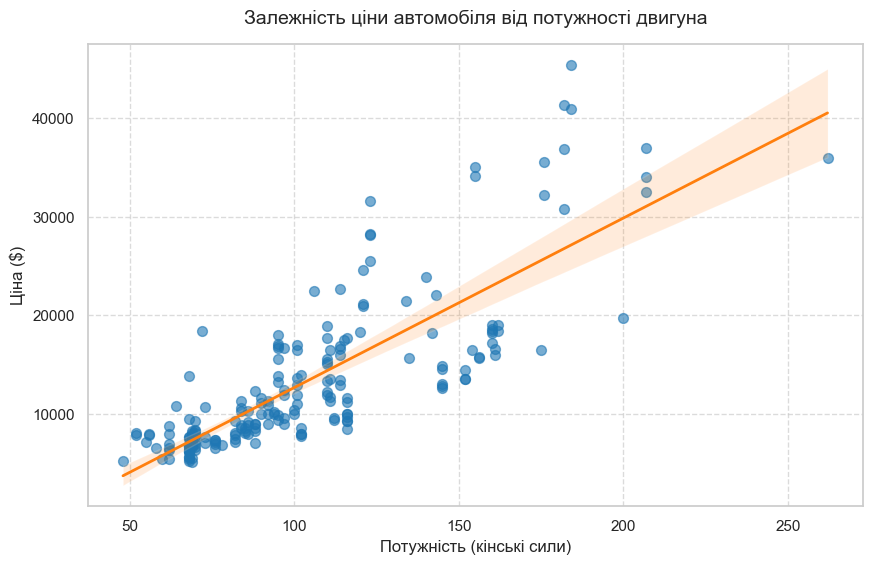

In [3]:
plt.figure(figsize=(10, 6))

sns.regplot(x='horsepower', y='price', data=df, 
            scatter_kws={'alpha':0.6, 's':50, 'color':'#1f77b4'}, 
            line_kws={'color':'#ff7f0e', 'linewidth':2})

plt.title('Залежність ціни автомобіля від потужності двигуна', fontsize=14, pad=15)
plt.xlabel('Потужність (кінські сили)', fontsize=12)
plt.ylabel('Ціна ($)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Побудова гістограми

**Завдання:** Побудувати гістограму по одному з атрибутів, що буде показувати кількість елементів у 5 заданих діапазонах.

Ми обрали атрибут `city-mpg` (витрата палива в місті - милі на галон). Ми розіб'ємо його рівно на 5 кошиків (bins), щоб побачити розподіл економічності автомобілів.

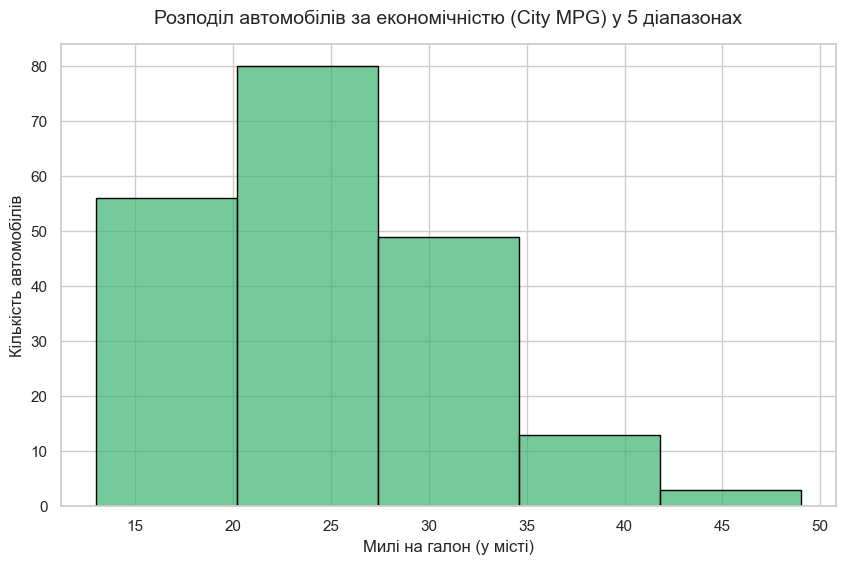

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(df['city-mpg'], bins=5, color='mediumseagreen', edgecolor='black', alpha=0.7)

plt.title('Розподіл автомобілів за економічністю (City MPG) у 5 діапазонах', fontsize=14, pad=15)
plt.xlabel('Милі на галон (у місті)', fontsize=12)
plt.ylabel('Кількість автомобілів', fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

# 4. Багатовимірний аналіз (Мульти-візуалізація)

**Завдання:** Побудувати графіки, використовуючи приклади, наведені у статті Medium про ефективну візуалізацію багатовимірних даних.

Тут ми проаналізуємо ціну автомобіля (`price`) залежно від типу кузова (`body-style`), і додатково розділимо їх за типом палива (`fuel-type`) за допомогою кольору (hue). Це дозволяє побачити, чи впливає тип кузова на ціну, і чи відрізняється ця залежність для бензинових та дизельних авто.

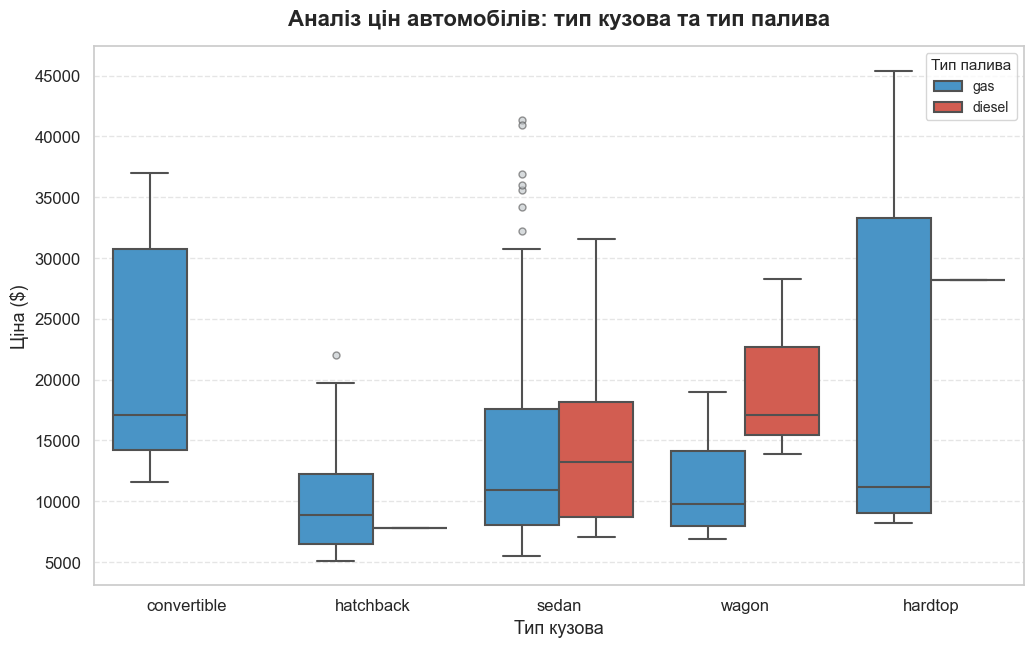

In [5]:
plt.figure(figsize=(12, 7))

sns.boxplot(x='body-style', y='price', hue='fuel-type', data=df, 
            palette={'gas':'#3498db', 'diesel':'#e74c3c'}, 
            linewidth=1.5,
            flierprops={'marker':'o', 'markerfacecolor':'#bdc3c7', 'markersize':5, 'alpha':0.6})

plt.title('Аналіз цін автомобілів: тип кузова та тип палива', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Тип кузова', fontsize=13)
plt.ylabel('Ціна ($)', fontsize=13)

plt.legend(title='Тип палива', title_fontsize='11', fontsize='10', loc='upper right')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# 5. Кореляційна матриця (Heatmap)

**Завдання:** Побудувати інші графіки, що покажуть корисну інформацію про датасет.

Ми обчислимо кореляцію (зв'язок) між усіма числовими атрибутами (horsepower, price, engine-size, mpg) та побудуємо теплову карту. Це допоможе нам швидко знайти, які параметри найбільше впливають один на одного.

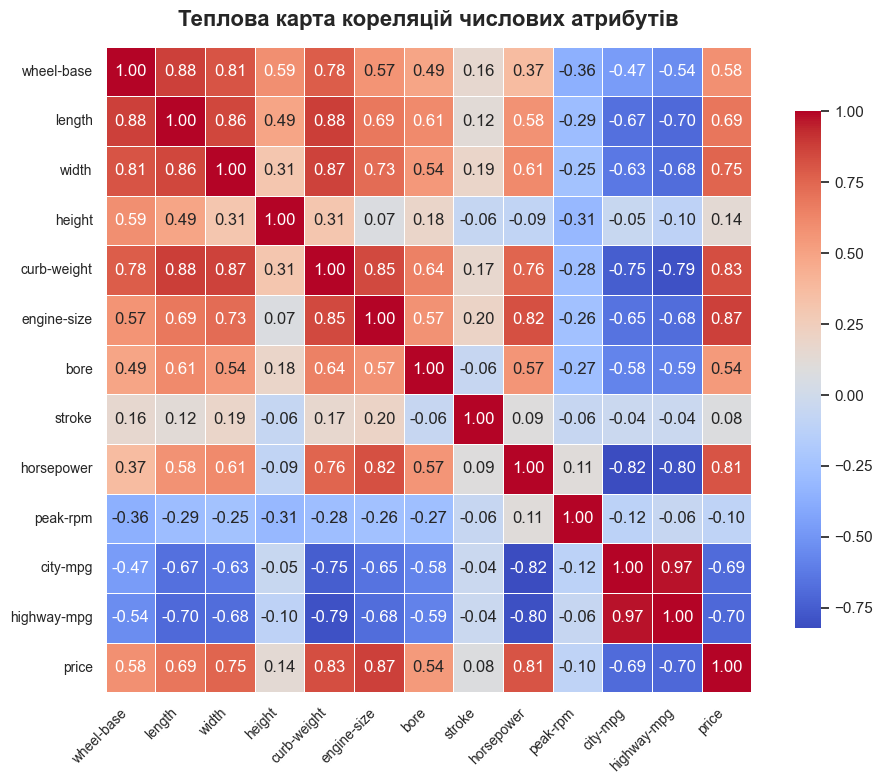

In [6]:
plt.figure(figsize=(10, 8))

numerical_cols = ['wheel-base', 'length', 'width', 'height', 'curb-weight', 
                  'engine-size', 'bore', 'stroke', 'horsepower', 'peak-rpm', 
                  'city-mpg', 'highway-mpg', 'price']

corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, square=True, cbar_kws={"shrink": .8})

plt.title('Теплова карта кореляцій числових атрибутів', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# 6. Лінійний графік (Lineplot) та Аналіз марок авто

**Завдання:** Побудувати графіки залежності (lineplot) та інші інформативні графіки (загальна кількість 5-8).

1. Будуємо `lineplot` для аналізу того, як змінюється ціна залежно від об'єму двигуна (`engine-size`). Бібліотека Seaborn автоматично розраховує середнє значення та показує довірчий інтервал (затінена область).
2. Будуємо горизонтальний `countplot` (стовпчикову діаграму), щоб побачити, які марки автомобілів (`make`) найчастіше зустрічаються в нашому датасеті.

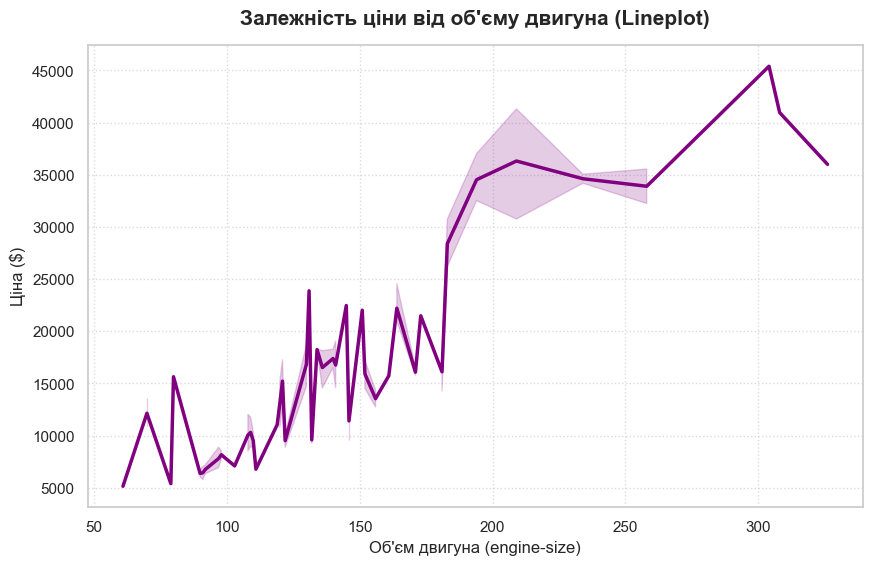

In [7]:
plt.figure(figsize=(10, 6))

sns.lineplot(x='engine-size', y='price', data=df, color='purple', linewidth=2.5)

plt.title("Залежність ціни від об'єму двигуна (Lineplot)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Об'єм двигуна (engine-size)", fontsize=12)
plt.ylabel("Ціна ($)", fontsize=12)

plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

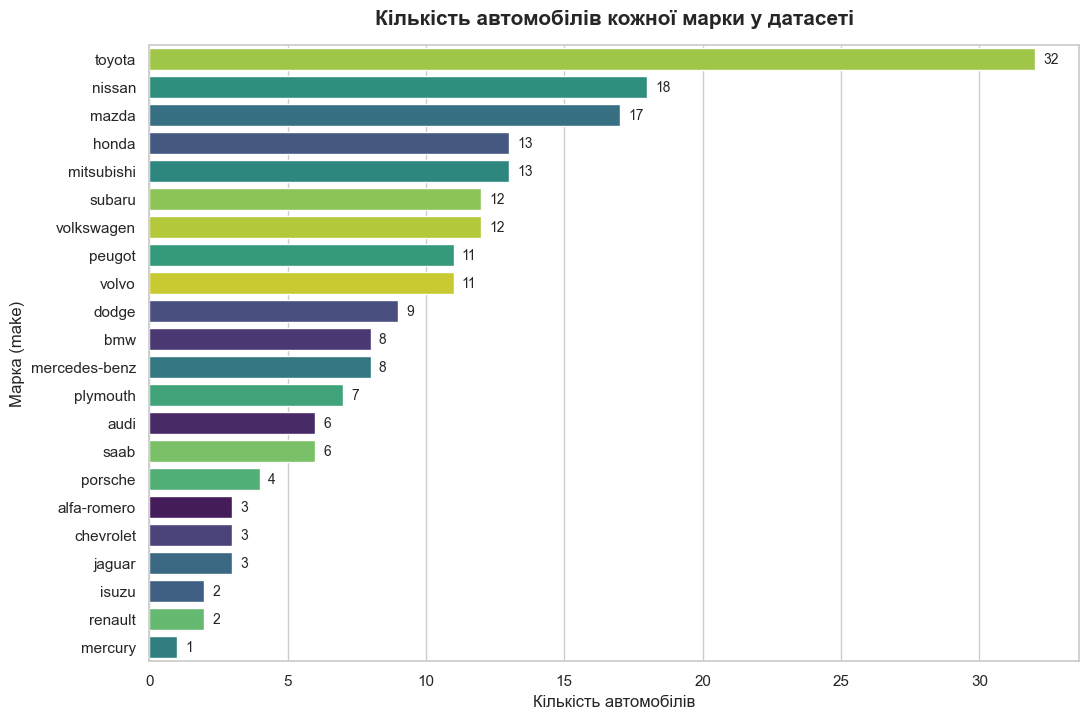

In [9]:
plt.figure(figsize=(12, 8))

order = df['make'].value_counts().index

sns.countplot(y='make', data=df, order=order, palette='viridis', hue='make', legend=False)

plt.title('Кількість автомобілів кожної марки у датасеті', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Кількість автомобілів', fontsize=12)
plt.ylabel('Марка (make)', fontsize=12)

for index, value in enumerate(df['make'].value_counts()):
    plt.text(value + 0.3, index + 0.15, str(value), fontsize=10)

plt.show()